# Sector factor risk model — 0/1 dummy exposures

A minimal fundamental factor model on the S&P 500. The only factors are the 11 GICS
sectors, and each stock's exposure is a 0/1 dummy (it's in the sector or it isn't):

$$r_t = X f_t + \varepsilon_t \qquad\Rightarrow\qquad \Sigma = X\,F\,X^\top + D$$

- $X$ — $N \times 11$ exposure matrix of sector dummies
- $f_t$ — daily factor returns, estimated by cross-sectional OLS
- $F$ — factor return covariance (annualized)
- $D$ — diagonal matrix of specific (residual) variances
- $\Sigma$ — the $N \times N$ asset covariance matrix the model produces

In [1]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

INK, MUTED, GRAY = '#0b0b0b', '#52514e', '#c9c8c2'
BLUE, AQUA, ORANGE, RED = '#2a78d6', '#1baf7a', '#eb6834', '#e34948'

plt.rcParams.update({
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.edgecolor': GRAY, 'axes.grid': True, 'axes.grid.axis': 'y',
    'grid.color': '#e8e7e3', 'grid.linewidth': 0.7,
    'axes.labelcolor': MUTED, 'xtick.color': MUTED, 'ytick.color': MUTED,
    'text.color': INK, 'font.size': 10, 'axes.titlesize': 12,
})

## 1. Data

Daily bars from the Databento pickle plus the GICS sector map. The universe is every
symbol that has both prices and a sector.

In [2]:
port_df = pd.read_pickle('../8YearsData.pkl')                # daily OHLCV, one row per (day, symbol)
gics = pd.read_csv('sp500.csv').set_index('Symbol')['GICS Sector']

sec = gics.reindex(port_df['symbol'].unique()).dropna().sort_index()   # symbol -> sector
len(sec)

503

## 2. Exposures

One 0/1 dummy per sector — each name loads on exactly one factor.

In [3]:
X = pd.get_dummies(sec).astype(float)                        # N x 11 exposure matrix
X.sum().astype(int)

Communication Services    23
Consumer Discretionary    47
Consumer Staples          34
Energy                    21
Financials                76
Health Care               59
Industrials               83
Information Technology    73
Materials                 25
Real Estate               31
Utilities                 31
dtype: int64

## 3. Returns

Pivot to a date × symbol close-price panel, take simple returns, and mask the
remaining bad prints. `fill_method=None` keeps gaps as NaN instead of padding
through halts and listings.

In [4]:
px = (port_df[port_df['symbol'].isin(sec.index)]
      .reset_index()
      .pivot(index='ts_event', columns='symbol', values='close'))

rets = px.pct_change(fill_method=None).iloc[1:]
rets = rets.mask(rets.abs() > 0.5)                           # kill remaining bad prints

X, sec = X.loc[rets.columns], sec.loc[rets.columns]
rets.shape, X.shape

((2078, 503), (503, 11))

## 4. Factor returns — one cross-sectional OLS per day

Each day, regress that day's stock returns on the sector dummies,
$\hat f_t = (X_t^\top X_t)^{-1} X_t^\top r_t$, using only the names that traded that day.

Because the dummies are disjoint, $X_t^\top X_t$ is diagonal (sector counts) and the
regression collapses to **the equal-weighted mean return of each sector's names** — so a
`groupby` runs all ~2,000 daily regressions at once and handles missing names day by day.
(A single full-sample matrix multiply would propagate NaNs on any day a name is missing,
and would use the wrong sector counts on those days.)

In [5]:
F = rets.T.groupby(sec).mean().T                             # T x 11 daily factor returns

# spot-check against the explicit OLS on one day
d = rets.notna().sum(axis=1).idxmax()
r = rets.loc[d].dropna()
Xd = X.loc[r.index].values
ols = np.linalg.solve(Xd.T @ Xd, Xd.T @ r.values)
print('matches explicit OLS:', np.allclose(ols, F.loc[d].values))
F.tail(3).round(4)

matches explicit OLS: True


GICS Sector,Communication Services,Consumer Discretionary,Consumer Staples,Energy,Financials,Health Care,Industrials,Information Technology,Materials,Real Estate,Utilities
ts_event,,,,,,,,,,,
2026-08-05 00:00:00+00:00,-0.0099,0.0065,-0.0032,-0.0220,0.0023,0.0036,-0.0014,-0.0167,0.0070,-0.0013,-0.0072
2026-08-06 00:00:00+00:00,-0.0002,-0.0055,-0.0047,0.0150,-0.0056,-0.0046,-0.0084,0.0089,-0.0046,-0.0131,-0.0056
2026-08-07 00:00:00+00:00,0.0080,0.0119,0.0042,-0.0121,-0.0015,0.0110,0.0058,0.0105,0.0100,0.0042,0.0033


## 5. Residuals and specific risk

$\varepsilon_t = r_t - X \hat f_t$. Each name's specific variance is the variance of its
residuals, annualized. With dummy exposures the residuals sum to zero within each sector
every day, by construction.

In [6]:
E = rets - F @ X.T                                           # T x N residuals
spec_var = E.var() * 252                                     # annualized specific variance
spec_vol = np.sqrt(spec_var)

print('max |within-sector residual sum|:', E.loc[d].groupby(sec).sum().abs().max())
spec_vol.describe().round(3)

max |within-sector residual sum|: 5.898059818321144e-17


count    503.000
mean       0.277
std        0.107
min        0.114
25%        0.215
50%        0.257
75%        0.308
max        1.003
dtype: float64

## 6. Factor covariance and the assembled model

Annualize the factor covariance and put the pieces together: $\Sigma = X F X^\top + D$.
Every pairwise stock covariance comes from the sector block; the diagonal adds specific
variance on top.

In [7]:
Fcov = F.cov() * 252                                         # 11 x 11, annualized

Sigma = pd.DataFrame(X.values @ Fcov.values @ X.values.T + np.diag(spec_var),
                     index=rets.columns, columns=rets.columns)
Sigma.iloc[:5, :5].round(4)

symbol,A,AAPL,ABBV,ABNB,ABT
symbol,,,,,
A,0.0818,0.0355,0.0338,0.0336,0.0338
AAPL,0.0355,0.1319,0.0355,0.0543,0.0355
ABBV,0.0338,0.0355,0.0836,0.0336,0.0338
ABNB,0.0336,0.0543,0.0336,0.1899,0.0336
ABT,0.0338,0.0355,0.0338,0.0336,0.0727


## 7. Diagnostics

- **Cross-sectional $R^2$** — how much of a typical day's cross-section the sector
  factors explain. Sector-only models usually land around 0.2–0.4.
- **Coverage** — the fewest names any sector has on a single day; the regression is only
  as good as its thinnest cross-section.

In [8]:
r2 = 1 - (E**2).sum(axis=1) / (rets**2).sum(axis=1)          # daily cross-sectional R2
print(f'mean cross-sectional R2: {r2.mean():.2f}')
print('fewest names on any day, per sector:')
rets.notna().T.groupby(sec).sum().T.min().astype(int)

mean cross-sectional R2: 0.29
fewest names on any day, per sector:


GICS Sector
Communication Services    18
Consumer Discretionary    44
Consumer Staples          32
Energy                    19
Financials                66
Health Care               53
Industrials               67
Information Technology    66
Materials                 19
Real Estate               30
Utilities                 29
dtype: int64

## 8. Factor returns over time

Cumulative return of each sector factor. The best two and worst cumulative performers
are highlighted; every line is labeled at its end.

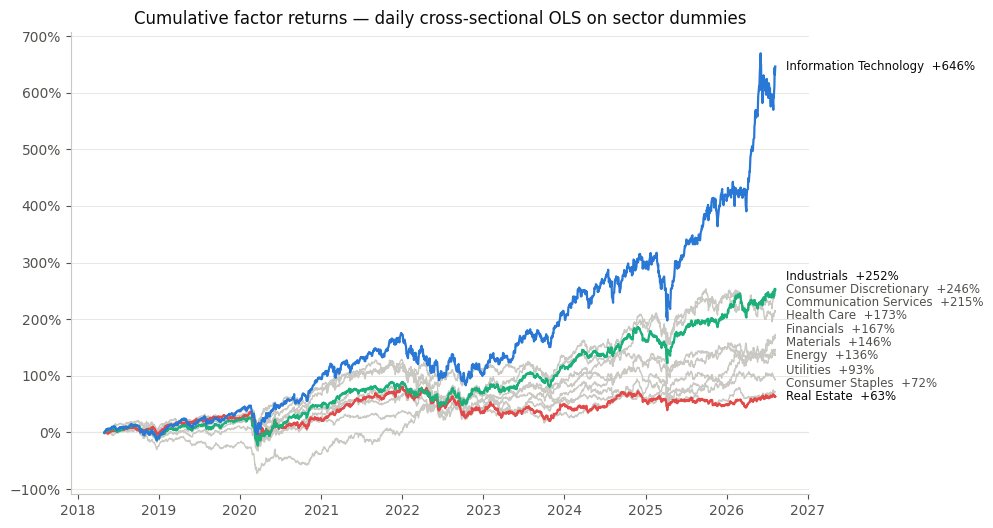

In [9]:
cum = (1 + F).cumprod() - 1
final = cum.iloc[-1]
order = final.sort_values(ascending=False)
hl = {order.index[0]: BLUE, order.index[1]: AQUA, order.index[-1]: RED}

fig, ax = plt.subplots(figsize=(12, 6))
fig.subplots_adjust(right=0.74)

for s in final.sort_values().index:
    ax.plot(cum.index, cum[s], lw=1.6 if s in hl else 1.0,
            color=hl.get(s, GRAY), zorder=3 if s in hl else 2)

# spread the end labels so they don't collide
lab = final.sort_values().copy()
gap = (cum.values.max() - cum.values.min()) / 32
for i in range(1, len(lab)):
    lab.iloc[i] = max(lab.iloc[i], lab.iloc[i - 1] + gap)

for s, y in lab.items():
    ax.annotate(f'{s}  {final[s]:+.0%}', (cum.index[-1], y),
                xytext=(8, 0), textcoords='offset points', va='center',
                fontsize=8.5, color=INK if s in hl else MUTED, clip_on=False)

ax.axhline(0, color=GRAY, lw=0.8, zorder=1)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1))
ax.set_title('Cumulative factor returns — daily cross-sectional OLS on sector dummies')
plt.show()

## 9. Factor covariance structure

Covariance and correlation of the daily factor returns (diverging scale, centered at
zero), then each factor's annualized volatility next to the median stock's specific
volatility — single-name risk is dominated by the specific term.

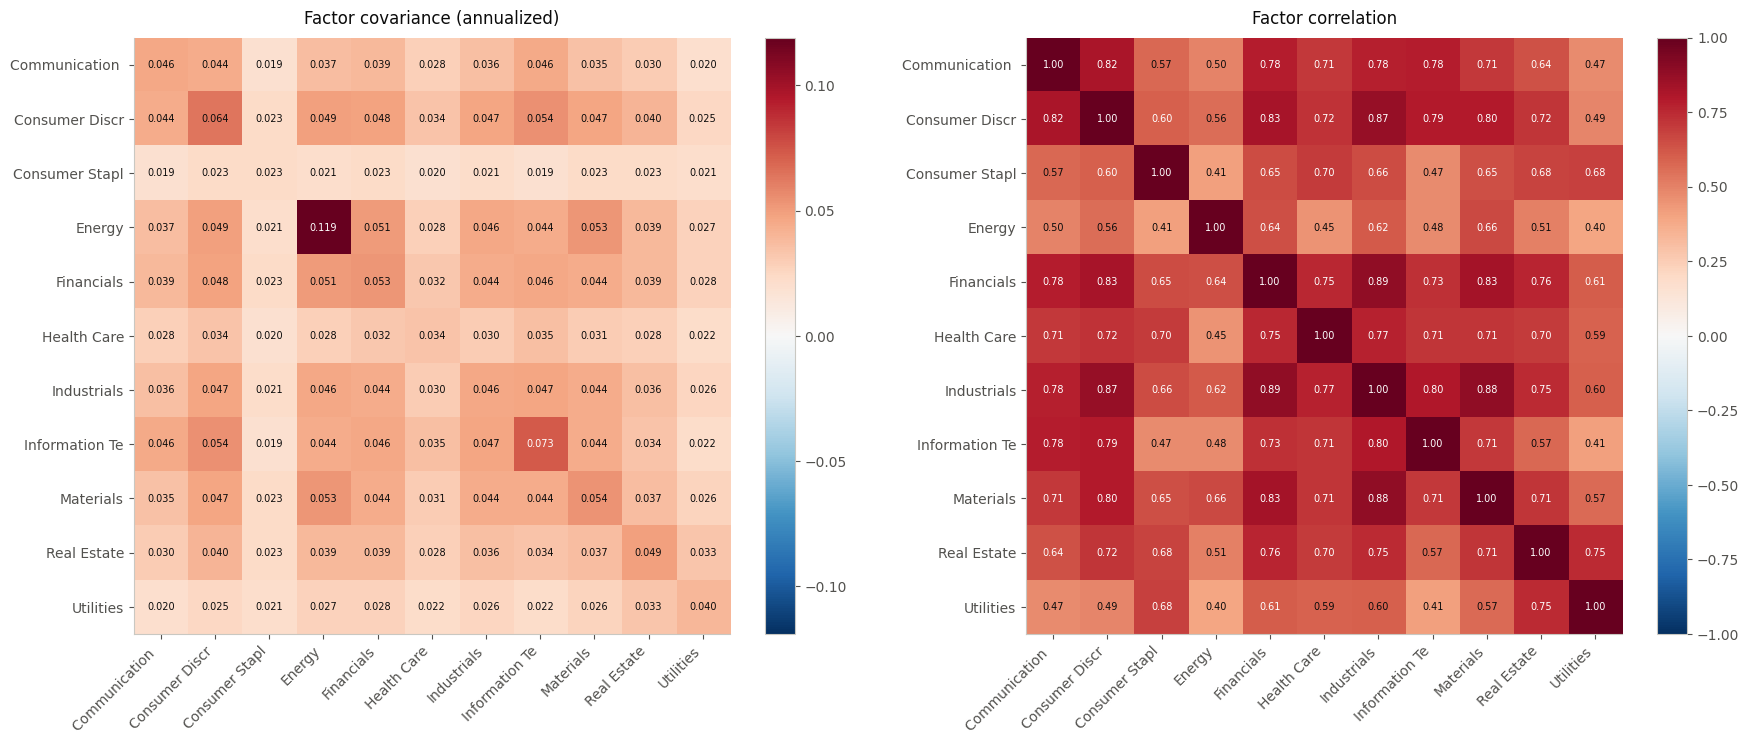

In [10]:
Fcorr = F.corr()
labels = [c[:14] for c in Fcov.columns]

fig, axes = plt.subplots(1, 2, figsize=(18, 7.5))
for ax, M, title, fmt in [
    (axes[0], Fcov,  'Factor covariance (annualized)', '{:.3f}'),
    (axes[1], Fcorr, 'Factor correlation',             '{:.2f}'),
]:
    v = np.abs(M.values).max()
    im = ax.imshow(M.values, cmap='RdBu_r', vmin=-v, vmax=v)
    ax.set_xticks(range(len(M)), labels, rotation=45, ha='right')
    ax.set_yticks(range(len(M)), labels)
    ax.set_title(title, pad=10)
    ax.grid(False)
    fig.colorbar(im, ax=ax, fraction=0.046)
    for i in range(len(M)):
        for j in range(len(M)):
            val = M.values[i, j]
            ax.text(j, i, fmt.format(val), ha='center', va='center', fontsize=7,
                    color='white' if abs(val) > 0.6 * v else INK)
plt.tight_layout()
plt.show()

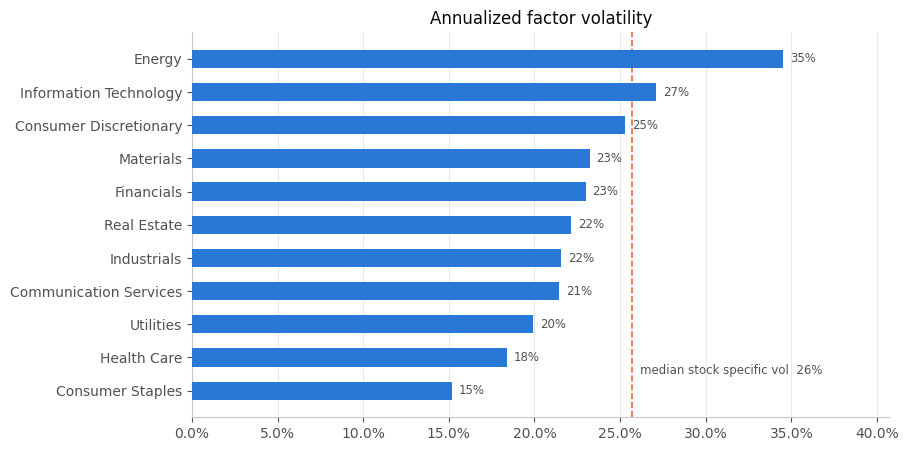

In [11]:
fac_vol = pd.Series(np.sqrt(np.diag(Fcov)), index=Fcov.columns).sort_values()

fig, ax = plt.subplots(figsize=(9, 5))
ax.grid(False, axis='y'); ax.grid(True, axis='x')
ax.barh(fac_vol.index, fac_vol.values, color=BLUE, height=0.55, zorder=3)
for i, v in enumerate(fac_vol.values):
    ax.text(v + 0.004, i, f'{v:.0%}', va='center', fontsize=8.5, color=MUTED)

med = spec_vol.median()
ax.axvline(med, color=ORANGE, lw=1.2, ls='--', zorder=2)
ax.text(med + 0.005, 0.6, f'median stock specific vol  {med:.0%}',
        va='center', fontsize=8.5, color=MUTED)

ax.set_xlim(0, max(fac_vol.max(), med) * 1.18)
ax.xaxis.set_major_formatter(mtick.PercentFormatter(1))
ax.set_title('Annualized factor volatility')
plt.show()

## 10. Using the model — portfolio risk

For weights $w$: total variance $w^\top \Sigma w$ splits into factor variance
$b^\top F b$ — where $b = X^\top w$ are the portfolio's sector exposures — and specific
variance $\sum_i w_i^2 D_{ii}$. Below, the equal-weighted portfolio of the full universe:
diversification kills most of the specific term, so nearly all remaining risk is factor
risk.

In [12]:
w = pd.Series(1 / len(sec), index=sec.index)                 # equal-weight portfolio

b        = X.T @ w                                           # portfolio sector exposures
var_fac  = b @ Fcov @ b
var_spec = (w**2 * spec_var).sum()
var_tot  = var_fac + var_spec
assert np.isclose(w @ Sigma @ w, var_tot)

print(f'portfolio vol : {np.sqrt(var_tot):7.2%}')
print(f'  factor      : {np.sqrt(var_fac):7.2%}   ({var_fac / var_tot:5.1%} of variance)')
print(f'  specific    : {np.sqrt(var_spec):7.2%}   ({var_spec / var_tot:5.1%} of variance)')

contrib = (b * (Fcov @ b) / var_tot).sort_values(ascending=False)
contrib.rename('share of portfolio variance').round(3).to_frame()

portfolio vol :  19.53%
  factor      :  19.49%   (99.5% of variance)
  specific    :   1.32%   ( 0.5% of variance)


,share of portfolio variance
Industrials,0.173
Information Technology,0.173
Financials,0.166
Consumer Discretionary,0.110
Health Care,0.094
Real Estate,0.057
Materials,0.053
Energy,0.049
Communication Services,0.043
Utilities,0.042
